# Gridlock Hackathon 2.0 — Advanced Model (Target: R² → 1.0)
**Strategy:** Maximum feature engineering + Optuna-tuned LightGBM / CatBoost / XGBoost + Neural stacking ensemble.

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc, re, math, time
from pathlib import Path

# Sklearn
from sklearn.model_selection import KFold, GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Boosting
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Geohash
try:
    import pygeohash as pgh
    GEOHASH_AVAIL = True
except ImportError:
    GEOHASH_AVAIL = False
    print("pygeohash not found — spatial decode skipped")

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data')
SUB_DIR  = Path('../submissions')
SUB_DIR.mkdir(exist_ok=True)

print("All imports OK")

All imports OK


## 2. Load Raw Data

In [2]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv')
test_raw  = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train: {train_raw.shape}   Test: {test_raw.shape}")
print("\nTrain columns:", train_raw.columns.tolist())
print("\nMissing in train:")
print(train_raw.isnull().sum())
print("\nMissing in test:")
print(test_raw.isnull().sum())

Train: (77299, 11)   Test: (41778, 10)

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

Missing in train:
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Missing in test:
Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64


## 3. Comprehensive Feature Engineering
All features are computed in a single deterministic function applied identically to train and test.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  GEOHASH DECODER (pure Python fallback if pygeohash missing)
# ─────────────────────────────────────────────────────────────────────────────
_BASE32 = '0123456789bcdefghjkmnpqrstuvwxyz'
_DECODE_MAP = {c: i for i, c in enumerate(_BASE32)}

def _decode_geohash(gh: str):
    """Return (lat, lon) centre of a geohash string."""
    if GEOHASH_AVAIL:
        d = pgh.decode(gh)
        return d[0], d[1]
    lat_range, lon_range = [-90.0, 90.0], [-180.0, 180.0]
    is_lon = True
    for c in gh:
        bits = _DECODE_MAP[c]
        for shift in (4, 3, 2, 1, 0):
            bit = (bits >> shift) & 1
            r = lon_range if is_lon else lat_range
            mid = (r[0] + r[1]) / 2
            if bit:
                r[0] = mid
            else:
                r[1] = mid
            is_lon = not is_lon
    return (lat_range[0]+lat_range[1])/2, (lon_range[0]+lon_range[1])/2

# ─────────────────────────────────────────────────────────────────────────────
#  HAVERSINE DISTANCE
# ─────────────────────────────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# ─────────────────────────────────────────────────────────────────────────────
#  LANDMARK DATABASE  (real-world anchor points for geospatial features)
# ─────────────────────────────────────────────────────────────────────────────
LANDMARKS = [
    # Airports
    {'name': 'KL_Intl_Airport',   'lat': 2.7456,   'lon': 101.7072, 'type': 'airport'},
    {'name': 'Subang_Airport',     'lat': 3.1306,   'lon': 101.5493, 'type': 'airport'},
    # City centres
    {'name': 'KLCC',               'lat': 3.1579,   'lon': 101.7116, 'type': 'commercial'},
    {'name': 'Bukit_Bintang',      'lat': 3.1467,   'lon': 101.7108, 'type': 'commercial'},
    # Stadiums
    {'name': 'Bukit_Jalil_Stadium','lat': 3.0574,   'lon': 101.6921, 'type': 'stadium'},
    # Hospitals
    {'name': 'HKL',                'lat': 3.1730,   'lon': 101.7036, 'type': 'hospital'},
    # Train/Transit hubs
    {'name': 'KL_Sentral',         'lat': 3.1342,   'lon': 101.6865, 'type': 'transit'},
    {'name': 'Midvalley',          'lat': 3.1184,   'lon': 101.6769, 'type': 'mall'},
]

# ─────────────────────────────────────────────────────────────────────────────
#  CORE FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
def parse_timestamp(ts_str):
    """'H:MM' → (hour, minute)"""
    parts = str(ts_str).split(':')
    return int(parts[0]), int(parts[1]) if len(parts) > 1 else 0

def add_time_features(df):
    hours, minutes = zip(*df['timestamp'].map(parse_timestamp))
    df = df.copy()
    df['hour']   = np.array(hours, dtype=np.int8)
    df['minute'] = np.array(minutes, dtype=np.int8)
    df['time_of_day_min'] = df['hour'] * 60 + df['minute']  # 0–1439

    # Cyclic encoding — prevents discontinuity at midnight / end of week
    df['hour_sin']  = np.sin(2 * np.pi * df['hour']   / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']   / 24)
    df['min_sin']   = np.sin(2 * np.pi * df['minute'] / 60)
    df['min_cos']   = np.cos(2 * np.pi * df['minute'] / 60)
    df['tod_sin']   = np.sin(2 * np.pi * df['time_of_day_min'] / 1440)
    df['tod_cos']   = np.cos(2 * np.pi * df['time_of_day_min'] / 1440)

    # Day cyclical (day ranges 1–7 based on observed data)
    day_max = df['day'].max()
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / max(day_max, 7))
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / max(day_max, 7))

    # Rush hours
    df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(np.int8)
    df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(np.int8)
    df['is_rush_hour']    = (df['is_morning_rush'] | df['is_evening_rush']).astype(np.int8)
    df['is_lunch_hour']   = ((df['hour'] >= 12) & (df['hour'] <= 13)).astype(np.int8)
    df['is_night']        = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(np.int8)
    df['is_off_peak']     = (~(df['is_rush_hour'].astype(bool)) & ~(df['is_night'].astype(bool))).astype(np.int8)

    # Shift bucket: 0=night, 1=morning, 2=afternoon, 3=evening
    df['time_shift'] = pd.cut(
        df['hour'],
        bins=[-1, 5, 11, 16, 23],
        labels=[0, 1, 2, 3]
    ).astype(np.int8)

    return df

def add_geo_features(df, geo_cache):
    """Decode geohash → lat/lon and add spatial proximity features."""
    df = df.copy()
    df['lat'] = df['geohash'].map(lambda g: geo_cache[g][0])
    df['lon'] = df['geohash'].map(lambda g: geo_cache[g][1])

    # Geohash prefix similarity features
    df['geo_prefix3'] = df['geohash'].str[:3]
    df['geo_prefix4'] = df['geohash'].str[:4]
    df['geo_prefix5'] = df['geohash'].str[:5]

    # Landmark proximity (Gaussian decay, σ=2km)
    sigma = 2.0
    prox_scores = np.zeros(len(df))
    min_dists   = np.full(len(df), 9999.0)
    nearest_type = ['none'] * len(df)

    for lm in LANDMARKS:
        dists = np.array([
            haversine_km(row_lat, row_lon, lm['lat'], lm['lon'])
            for row_lat, row_lon in zip(df['lat'], df['lon'])
        ])
        prox_scores += np.exp(-(dists**2) / (2 * sigma**2))
        update_mask = dists < min_dists
        min_dists = np.where(update_mask, dists, min_dists)
        nearest_type = [lm['type'] if update_mask[i] else nearest_type[i] for i in range(len(df))]

    df['landmark_proximity_score'] = prox_scores
    df['nearest_landmark_km']      = min_dists
    df['nearest_landmark_type']    = nearest_type

    # City centre distance
    klcc_lat, klcc_lon = 3.1579, 101.7116
    df['dist_city_centre_km'] = [
        haversine_km(lat, lon, klcc_lat, klcc_lon)
        for lat, lon in zip(df['lat'], df['lon'])
    ]
    df['log_dist_city_centre'] = np.log1p(df['dist_city_centre_km'])

    return df

def add_weather_features(df):
    df = df.copy()

    # Binary weather flags
    df['is_sunny'] = (df['Weather'] == 'Sunny').astype(np.int8)
    df['is_rainy'] = (df['Weather'] == 'Rainy').astype(np.int8)
    df['is_foggy'] = (df['Weather'] == 'Foggy').astype(np.int8)
    df['is_snowy'] = (df['Weather'] == 'Snowy').astype(np.int8)
    df['bad_weather'] = (df['is_rainy'] | df['is_foggy'] | df['is_snowy']).astype(np.int8)

    # Temperature bins and thresholds
    df['is_hot']  = (df['Temperature'] > 35).astype(np.int8)
    df['is_cold'] = (df['Temperature'] < 15).astype(np.int8)
    df['temp_bin'] = pd.cut(
        df['Temperature'],
        bins=[-np.inf, 5, 15, 25, 35, np.inf],
        labels=[0, 1, 2, 3, 4]
    ).astype('float32')

    # Cyclic temperature (annual cycle proxy 0–40 °C)
    df['temp_norm'] = (df['Temperature'] - df['Temperature'].mean()) / (df['Temperature'].std() + 1e-6)

    return df

def add_road_features(df):
    df = df.copy()
    road_order = {'Residential': 1, 'Local': 2, 'Collector': 3, 'Arterial': 3,
                  'Highway': 4, 'Expressway': 4, 'Unknown': 2}
    df['road_capacity_score'] = df['RoadType'].map(road_order).fillna(2).astype(np.int8)
    df['road_capacity_proxy'] = df['road_capacity_score'] * df['NumberofLanes'].fillna(1)
    df['has_landmarks']       = (df['Landmarks'] == 'Yes').astype(np.int8)
    df['large_vehicles_allowed'] = (df['LargeVehicles'] == 'Allowed').astype(np.int8)

    # Road complexity index
    df['road_complexity'] = (
        df['road_capacity_score'] * 
        df['NumberofLanes'].fillna(1) * 
        (1 + df['has_landmarks']) * 
        (1 + df['large_vehicles_allowed'])
    )
    return df

def add_interaction_features(df):
    df = df.copy()

    # Weather × rush hour
    df['rain_x_rush']    = df['is_rainy'] * df['is_rush_hour']
    df['fog_x_rush']     = df['is_foggy'] * df['is_rush_hour']
    df['bad_wx_x_rush']  = df['bad_weather'] * df['is_rush_hour']

    # Temperature × time-of-day
    df['temp_x_hour']    = df['Temperature'].fillna(df['Temperature'].median()) * df['hour']
    df['temp_x_shift']   = df['Temperature'].fillna(df['Temperature'].median()) * df['time_shift'].astype(float)

    # Road × time
    df['capacity_x_rush'] = df['road_capacity_proxy'] * df['is_rush_hour']
    df['lanes_x_rush']    = df['NumberofLanes'].fillna(1) * df['is_rush_hour']

    # Spatial × weather
    df['proximity_x_rush'] = df['landmark_proximity_score'] * df['is_rush_hour']

    # Hour squared (non-linear)
    df['hour_sq']  = df['hour'] ** 2
    df['hour_cub'] = df['hour'] ** 3

    return df

print("Feature functions defined")

Feature functions defined


## 4. Target-Encoding & Lag/Rolling Features (OOF-safe)

In [4]:
def add_frequency_encoding(df_train, df_test, col):
    """Normalised frequency of each category (train distribution only)."""
    freq = df_train[col].value_counts(normalize=True)
    df_train = df_train.copy()
    df_test  = df_test.copy()
    df_train[f'{col}_freq'] = df_train[col].map(freq).fillna(0)
    df_test[f'{col}_freq']  = df_test[col].map(freq).fillna(0)
    return df_train, df_test


def add_oof_target_encoding(df_train, df_test, col, target_col='demand',
                             n_splits=5, smoothing=10, seed=42):
    """
    Out-of-fold smoothed target encoding — zero leakage.
    smoothed_mean = (n * cat_mean + smoothing * global_mean) / (n + smoothing)
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()
    global_mean = df_train[target_col].mean()
    new_col = f'{col}_target_enc'
    df_train[new_col] = np.nan

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(df_train):
        fold_tr = df_train.iloc[tr_idx]
        stats = fold_tr.groupby(col)[target_col].agg(['mean', 'count'])
        smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        df_train.loc[df_train.index[val_idx], new_col] = \
            df_train.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    # Test: use full-train stats
    stats = df_train.groupby(col)[target_col].agg(['mean', 'count'])
    smoothed_full = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    df_test[new_col] = df_test[col].map(smoothed_full).fillna(global_mean)

    return df_train, df_test


def add_geohash_hour_stats(df_train, df_test):
    """Historical mean/std of demand per (geohash, hour) — powerful temporal-spatial feature."""
    df_train = df_train.copy()
    df_test  = df_test.copy()
    stats = df_train.groupby(['geohash', 'hour'])['demand'].agg(['mean', 'std', 'count']).reset_index()
    stats.columns = ['geohash', 'hour', 'gh_hour_mean', 'gh_hour_std', 'gh_hour_cnt']
    df_train = df_train.merge(stats, on=['geohash', 'hour'], how='left')
    df_test  = df_test.merge(stats, on=['geohash', 'hour'], how='left')
    global_mean = df_train['demand'].mean() if 'demand' in df_train else 0
    df_test['gh_hour_mean'].fillna(global_mean, inplace=True)
    df_test['gh_hour_std'].fillna(0, inplace=True)
    df_test['gh_hour_cnt'].fillna(0, inplace=True)
    return df_train, df_test


def add_geohash_day_stats(df_train, df_test):
    """Mean demand per (geohash, day) from train."""
    df_train = df_train.copy()
    df_test  = df_test.copy()
    stats = df_train.groupby(['geohash', 'day'])['demand'].agg(['mean', 'std']).reset_index()
    stats.columns = ['geohash', 'day', 'gh_day_mean', 'gh_day_std']
    df_train = df_train.merge(stats, on=['geohash', 'day'], how='left')
    df_test  = df_test.merge(stats, on=['geohash', 'day'], how='left')
    gm = df_train['demand'].mean() if 'demand' in df_train else 0
    df_test['gh_day_mean'].fillna(gm, inplace=True)
    df_test['gh_day_std'].fillna(0, inplace=True)
    return df_train, df_test


def add_lag_rolling_features(df_train, df_test):
    """
    Compute lag and rolling demand features per geohash.
    Strategy: sort by (geohash, day, hour, minute) and shift within group.
    Test rows appended temporarily for back-fill.
    """
    # We need demand in test to be NaN — that's natural
    df_train = df_train.copy()
    df_test  = df_test.copy()
    df_test['demand'] = np.nan  # placeholder

    combined = pd.concat([df_train, df_test], ignore_index=True)
    combined['_sort_key'] = combined['day'] * 10000 + combined['hour'] * 100 + combined['minute']
    combined = combined.sort_values(['geohash', '_sort_key']).reset_index(drop=True)

    # Lag features
    for lag in [1, 2, 3, 6, 24]:
        combined[f'demand_lag_{lag}'] = combined.groupby('geohash')['demand'].shift(lag)

    # Rolling features (after shift to avoid leakage)
    grp = combined.groupby('geohash')['demand']
    for window in [3, 6, 24]:
        combined[f'demand_roll_mean_{window}'] = grp.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        combined[f'demand_roll_std_{window}'] = grp.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0)
        )
    combined[f'demand_roll_max_6'] = grp.transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).max()
    )
    combined[f'demand_roll_min_6'] = grp.transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).min()
    )

    # Expanding mean (very long-term baseline per cell)
    combined['demand_expanding_mean'] = grp.transform(
        lambda x: x.shift(1).expanding().mean()
    )

    combined.drop(columns=['_sort_key'], inplace=True)

    # Split back
    is_test = combined['demand'].isna()
    df_train_out = combined[~is_test].copy()
    df_test_out  = combined[is_test].drop(columns=['demand']).copy()

    lag_cols = [c for c in combined.columns if 'lag' in c or 'roll' in c or 'expanding' in c]
    for col in lag_cols:
        df_train_out[col].fillna(df_train_out[col].median(), inplace=True)
        df_test_out[col].fillna(df_train_out[col].median(), inplace=True)

    return df_train_out, df_test_out

print("Encoding & lag functions defined")

Encoding & lag functions defined


## 5. Build Full Feature Matrix

In [5]:
def build_geo_cache(df_train, df_test):
    all_geohashes = set(df_train['geohash'].unique()) | set(df_test['geohash'].unique())
    cache = {}
    for gh in all_geohashes:
        try:
            cache[gh] = _decode_geohash(gh)
        except Exception:
            cache[gh] = (3.1579, 101.7116)  # KL centre fallback
    return cache

def preprocess(df):
    """Clean raw dataframe: fill NaN, normalise strings."""
    df = df.copy()
    # Categorical missing → 'Unknown'
    for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()
    # Temperature NaN: will be imputed using train median later
    return df


def full_pipeline(df_train_raw, df_test_raw):
    print("[1/8] Preprocessing...")
    tr = preprocess(df_train_raw)
    te = preprocess(df_test_raw)

    # Impute temperature with train median
    temp_median = tr['Temperature'].median()
    tr['Temperature'] = tr['Temperature'].fillna(temp_median)
    te['Temperature'] = te['Temperature'].fillna(temp_median)

    print("[2/8] Building geo cache...")
    geo_cache = build_geo_cache(tr, te)

    print("[3/8] Time features...")
    tr = add_time_features(tr)
    te = add_time_features(te)

    print("[4/8] Geo/spatial features...")
    tr = add_geo_features(tr, geo_cache)
    te = add_geo_features(te, geo_cache)

    print("[5/8] Weather & road features...")
    tr = add_weather_features(tr)
    tr = add_road_features(tr)
    te = add_weather_features(te)
    te = add_road_features(te)

    print("[6/8] Statistical encodings (geohash × hour, geohash × day)...")
    tr, te = add_geohash_hour_stats(tr, te)
    tr, te = add_geohash_day_stats(tr, te)

    print("[7/8] Lag & rolling demand features...")
    tr, te = add_lag_rolling_features(tr, te)

    print("[8/8] OOF target encoding & frequency encoding...")
    for col in ['geohash', 'geo_prefix3', 'geo_prefix4', 'geo_prefix5',
                'RoadType', 'Weather', 'nearest_landmark_type']:
        tr, te = add_oof_target_encoding(tr, te, col)
        tr, te = add_frequency_encoding(tr, te, col)

    # Interaction features (need weather & time already computed)
    tr = add_interaction_features(tr)
    te = add_interaction_features(te)

    print(f"\n✓ Train shape: {tr.shape}   Test shape: {te.shape}")
    return tr, te, geo_cache


print("Starting full pipeline...")
t0 = time.time()
train_fe, test_fe, geo_cache = full_pipeline(train_raw, test_raw)
print(f"Pipeline completed in {time.time()-t0:.1f}s")

Starting full pipeline...
[1/8] Preprocessing...
[2/8] Building geo cache...
[3/8] Time features...
[4/8] Geo/spatial features...
[5/8] Weather & road features...
[6/8] Statistical encodings (geohash × hour, geohash × day)...
[7/8] Lag & rolling demand features...
[8/8] OOF target encoding & frequency encoding...

✓ Train shape: (77299, 96)   Test shape: (41778, 95)
Pipeline completed in 23.4s


## 6. Prepare Feature Matrices for Modelling

In [6]:
# ─── Identify feature columns ──────────────────────────────────────────────
DROP_COLS = ['Index', 'demand', 'timestamp', 'geohash',
             'geo_prefix3', 'geo_prefix4', 'geo_prefix5',
             'RoadType', 'Weather', 'nearest_landmark_type',
             'LargeVehicles', 'Landmarks']

# Encode remaining object columns (safety net)
def label_encode_objects(df_train, df_test):
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for col in df_train.select_dtypes('object').columns:
        if col in DROP_COLS:
            continue
        le = LabelEncoder()
        all_vals = pd.concat([df_train[col], df_test[col]], axis=0).astype(str)
        le.fit(all_vals)
        df_train[col] = le.transform(df_train[col].astype(str))
        df_test[col]  = le.transform(df_test[col].astype(str))
    return df_train, df_test

train_fe, test_fe = label_encode_objects(train_fe, test_fe)

FEATURE_COLS = [c for c in train_fe.columns
                if c not in DROP_COLS and c != 'demand'
                and train_fe[c].dtype != 'object']

TARGET = 'demand'

X = train_fe[FEATURE_COLS].values.astype(np.float32)
y = train_fe[TARGET].values.astype(np.float32)
X_test = test_fe[FEATURE_COLS].values.astype(np.float32)

print(f"Feature count: {len(FEATURE_COLS)}")
print(f"X: {X.shape}   X_test: {X_test.shape}")
print("\nSample feature list:")
for i, f in enumerate(FEATURE_COLS):
    print(f"  {i:3d}. {f}")

Feature count: 84
X: (77299, 84)   X_test: (41778, 84)

Sample feature list:
    0. day
    1. NumberofLanes
    2. Temperature
    3. hour
    4. minute
    5. time_of_day_min
    6. hour_sin
    7. hour_cos
    8. min_sin
    9. min_cos
   10. tod_sin
   11. tod_cos
   12. day_sin
   13. day_cos
   14. is_morning_rush
   15. is_evening_rush
   16. is_rush_hour
   17. is_lunch_hour
   18. is_night
   19. is_off_peak
   20. time_shift
   21. lat
   22. lon
   23. landmark_proximity_score
   24. nearest_landmark_km
   25. dist_city_centre_km
   26. log_dist_city_centre
   27. is_sunny
   28. is_rainy
   29. is_foggy
   30. is_snowy
   31. bad_weather
   32. is_hot
   33. is_cold
   34. temp_bin
   35. temp_norm
   36. road_capacity_score
   37. road_capacity_proxy
   38. has_landmarks
   39. large_vehicles_allowed
   40. road_complexity
   41. gh_hour_mean
   42. gh_hour_std
   43. gh_hour_cnt
   44. gh_day_mean
   45. gh_day_std
   46. demand_lag_1
   47. demand_lag_2
   48. demand_lag

## 7. CV Utilities

In [7]:
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

def evaluate_r2(y_true, y_pred):
    return r2_score(y_true, np.clip(y_pred, 0, None))

def oof_predict(model_fn, X, y, X_test, kf, model_name='model'):
    """
    Run out-of-fold predictions.
    model_fn(X_tr, y_tr, X_val) → (val_preds, test_preds)
    Returns (oof_preds, test_preds_averaged, fold_scores)
    """
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        val_pred, test_pred = model_fn(X_tr, y_tr, X_val, X_test)

        oof[val_idx] = val_pred
        test_preds  += test_pred / N_SPLITS
        score = evaluate_r2(y_val, val_pred)
        scores.append(score)
        print(f"  Fold {fold+1}/{N_SPLITS}  R²={score:.5f}")

    overall = evaluate_r2(y, oof)
    print(f"  {model_name} OOF R²={overall:.5f}  mean-fold={np.mean(scores):.5f}")
    return oof, test_preds, scores

print("CV utilities ready")

CV utilities ready


## 8. LightGBM — Optuna Hyperparameter Optimisation

In [8]:
def lgb_objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'rmse',
        'verbosity':         -1,
        'boosting_type':     'gbdt',
        'n_estimators':      trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 512),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
        'seed':              SEED,
        'n_jobs':            -1,
    }

    oof_scores = []
    for tr_idx, val_idx in kf.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )
        preds = model.predict(X_val)
        oof_scores.append(evaluate_r2(y_val, preds))

    return np.mean(oof_scores)


print("Optimising LightGBM with Optuna (50 trials)...")
lgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

best_lgb_params = lgb_study.best_params
best_lgb_params.update({
    'objective': 'regression', 'metric': 'rmse',
    'verbosity': -1, 'subsample_freq': 1, 'seed': SEED, 'n_jobs': -1
})
print(f"\nBest LGB R²={lgb_study.best_value:.5f}")
print(best_lgb_params)

Optimising LightGBM with Optuna (50 trials)...


Best trial: 41. Best value: 0.975607: 100%|██████████| 50/50 [20:00<00:00, 24.01s/it]


Best LGB R²=0.97561
{'n_estimators': 1222, 'learning_rate': 0.018808970689961943, 'num_leaves': 323, 'max_depth': 10, 'min_child_samples': 86, 'subsample': 0.7869867565743222, 'colsample_bytree': 0.7441957081892101, 'reg_alpha': 2.6026300528428876e-06, 'reg_lambda': 9.142331383582724e-07, 'min_split_gain': 0.002019030692522017, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'subsample_freq': 1, 'seed': 42, 'n_jobs': -1}


## 9. CatBoost — Optuna Hyperparameter Optimisation

In [9]:
def cb_objective(trial):
    params = {
        'iterations':           trial.suggest_int('iterations', 500, 2000),
        'learning_rate':        trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth':                trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':          trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'bagging_temperature':  trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':      trial.suggest_float('random_strength', 0.5, 10.0, log=True),
        'min_data_in_leaf':     trial.suggest_int('min_data_in_leaf', 1, 50),
        'border_count':         trial.suggest_int('border_count', 32, 255),
        'od_type':              'Iter',
        'od_wait':              50,
        'loss_function':        'RMSE',
        'eval_metric':          'R2',
        'random_seed':          SEED,
        'verbose':              False,
    }

    oof_scores = []
    for tr_idx, val_idx in kf.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
        preds = model.predict(X_val)
        oof_scores.append(evaluate_r2(y_val, preds))

    return np.mean(oof_scores)


print("Optimising CatBoost with Optuna (50 trials)...")
cb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True)

best_cb_params = cb_study.best_params
best_cb_params.update({
    'od_type': 'Iter', 'od_wait': 50,
    'loss_function': 'RMSE', 'eval_metric': 'R2',
    'random_seed': SEED, 'verbose': False
})
print(f"\nBest CB R²={cb_study.best_value:.5f}")
print(best_cb_params)

Optimising CatBoost with Optuna (50 trials)...


Best trial: 24. Best value: 0.978007: 100%|██████████| 50/50 [3:35:40<00:00, 258.82s/it]  


Best CB R²=0.97801
{'iterations': 1623, 'learning_rate': 0.0301679732613887, 'depth': 7, 'l2_leaf_reg': 3.8453970186476205, 'bagging_temperature': 0.36064452412800374, 'random_strength': 2.6870709617718966, 'min_data_in_leaf': 14, 'border_count': 254, 'od_type': 'Iter', 'od_wait': 50, 'loss_function': 'RMSE', 'eval_metric': 'R2', 'random_seed': 42, 'verbose': False}


## 10. XGBoost — Optuna Hyperparameter Optimisation

In [10]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective':        'reg:squarederror',
        'tree_method':      'hist',
        'seed':             SEED,
        'n_jobs':           -1,
        'verbosity':        0,
    }

    oof_scores = []
    for tr_idx, val_idx in kf.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        oof_scores.append(evaluate_r2(y_val, preds))

    return np.mean(oof_scores)


print("Optimising XGBoost with Optuna (40 trials)...")
xgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

best_xgb_params = xgb_study.best_params
best_xgb_params.update({
    'objective': 'reg:squarederror', 'tree_method': 'hist',
    'seed': SEED, 'n_jobs': -1, 'verbosity': 0
})
print(f"\nBest XGB R²={xgb_study.best_value:.5f}")
print(best_xgb_params)

Optimising XGBoost with Optuna (40 trials)...


Best trial: 30. Best value: 0.974976: 100%|██████████| 40/40 [36:22<00:00, 54.55s/it] 


Best XGB R²=0.97498
{'n_estimators': 667, 'learning_rate': 0.04525061447750377, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8634924272824348, 'colsample_bytree': 0.7451195658304691, 'gamma': 0.014772936019026002, 'reg_alpha': 1.103154280517395e-06, 'reg_lambda': 2.7821769173219455e-07, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'seed': 42, 'n_jobs': -1, 'verbosity': 0}


## 11. OOF Predictions from All Base Models

In [11]:
# ─── LightGBM ──────────────────────────────────────────────────────────────
def lgb_model_fn(X_tr, y_tr, X_val, X_test):
    model = lgb.LGBMRegressor(**best_lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    return model.predict(X_val), model.predict(X_test)

# Use closure to pass y_val correctly inside oof_predict
lgb_models = []
lgb_oof    = np.zeros(len(y))
lgb_test   = np.zeros(len(X_test))
lgb_scores = []

print("--- LightGBM OOF ---")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val_f = X[tr_idx], X[val_idx]
    y_tr, y_val_f = y[tr_idx], y[val_idx]
    m = lgb.LGBMRegressor(**best_lgb_params)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val_f, y_val_f)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    val_pred  = m.predict(X_val_f)
    lgb_oof[val_idx] = val_pred
    lgb_test += m.predict(X_test) / N_SPLITS
    lgb_models.append(m)
    s = evaluate_r2(y_val_f, val_pred)
    lgb_scores.append(s)
    print(f"  Fold {fold+1}  R²={s:.5f}")

print(f"LGB OOF R²={evaluate_r2(y, lgb_oof):.5f}  mean={np.mean(lgb_scores):.5f}")

--- LightGBM OOF ---
  Fold 1  R²=0.97590
  Fold 2  R²=0.97450
  Fold 3  R²=0.97600
  Fold 4  R²=0.97664
  Fold 5  R²=0.97500
LGB OOF R²=0.97560  mean=0.97561


In [12]:
# ─── CatBoost ──────────────────────────────────────────────────────────────
cb_models  = []
cb_oof     = np.zeros(len(y))
cb_test    = np.zeros(len(X_test))
cb_scores  = []

print("--- CatBoost OOF ---")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val_f = X[tr_idx], X[val_idx]
    y_tr, y_val_f = y[tr_idx], y[val_idx]
    m = CatBoostRegressor(**best_cb_params)
    m.fit(X_tr, y_tr, eval_set=(X_val_f, y_val_f), verbose=False)
    val_pred = m.predict(X_val_f)
    cb_oof[val_idx] = val_pred
    cb_test += m.predict(X_test) / N_SPLITS
    cb_models.append(m)
    s = evaluate_r2(y_val_f, val_pred)
    cb_scores.append(s)
    print(f"  Fold {fold+1}  R²={s:.5f}")

print(f"CB  OOF R²={evaluate_r2(y, cb_oof):.5f}  mean={np.mean(cb_scores):.5f}")

--- CatBoost OOF ---
  Fold 1  R²=0.97794
  Fold 2  R²=0.97771
  Fold 3  R²=0.97757
  Fold 4  R²=0.97903
  Fold 5  R²=0.97779
CB  OOF R²=0.97802  mean=0.97801


In [13]:
# ─── XGBoost ───────────────────────────────────────────────────────────────
xgb_models = []
xgb_oof    = np.zeros(len(y))
xgb_test   = np.zeros(len(X_test))
xgb_scores = []

print("--- XGBoost OOF ---")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val_f = X[tr_idx], X[val_idx]
    y_tr, y_val_f = y[tr_idx], y[val_idx]
    m = xgb.XGBRegressor(**best_xgb_params, early_stopping_rounds=50)
    m.fit(X_tr, y_tr, eval_set=[(X_val_f, y_val_f)], verbose=False)
    val_pred = m.predict(X_val_f)
    xgb_oof[val_idx] = val_pred
    xgb_test += m.predict(X_test) / N_SPLITS
    xgb_models.append(m)
    s = evaluate_r2(y_val_f, val_pred)
    xgb_scores.append(s)
    print(f"  Fold {fold+1}  R²={s:.5f}")

print(f"XGB OOF R²={evaluate_r2(y, xgb_oof):.5f}  mean={np.mean(xgb_scores):.5f}")

--- XGBoost OOF ---
  Fold 1  R²=0.97376
  Fold 2  R²=0.97497
  Fold 3  R²=0.97503
  Fold 4  R²=0.97598
  Fold 5  R²=0.97514
XGB OOF R²=0.97498  mean=0.97498


## 12. Advanced Ensemble Methods

In [14]:
# ─── 12a. Optimal Weighted Average (grid search on OOF) ────────────────────
from itertools import product

best_w, best_r2 = None, -np.inf
for w_lgb, w_cb, w_xgb in product(np.arange(0, 1.01, 0.05), repeat=3):
    if abs(w_lgb + w_cb + w_xgb - 1.0) > 0.01:
        continue
    blend_oof = w_lgb * lgb_oof + w_cb * cb_oof + w_xgb * xgb_oof
    r2 = evaluate_r2(y, blend_oof)
    if r2 > best_r2:
        best_r2 = r2
        best_w  = (w_lgb, w_cb, w_xgb)

print(f"Optimal weights → LGB={best_w[0]:.2f}  CB={best_w[1]:.2f}  XGB={best_w[2]:.2f}")
print(f"Weighted-avg OOF R²={best_r2:.5f}")

weighted_test = best_w[0]*lgb_test + best_w[1]*cb_test + best_w[2]*xgb_test

# ─── 12b. Ridge Meta-Learner (Stacking) ────────────────────────────────────
S_oof  = np.column_stack([lgb_oof,  cb_oof,  xgb_oof])
S_test = np.column_stack([lgb_test, cb_test, xgb_test])

meta_scores = []
meta_oof    = np.zeros(len(y))
meta_test   = np.zeros(len(X_test))

for tr_idx, val_idx in kf.split(S_oof, y):
    meta = Ridge(alpha=1.0)
    meta.fit(S_oof[tr_idx], y[tr_idx])
    meta_oof[val_idx] = meta.predict(S_oof[val_idx])
    meta_test += meta.predict(S_test) / N_SPLITS
    meta_scores.append(evaluate_r2(y[val_idx], meta_oof[val_idx]))

print(f"\nRidge stacking OOF R²={evaluate_r2(y, meta_oof):.5f}  mean-fold={np.mean(meta_scores):.5f}")

# ─── 12c. LightGBM Meta-Learner (deeper stacking) ──────────────────────────
lgb_meta_oof  = np.zeros(len(y))
lgb_meta_test = np.zeros(len(X_test))
lgb_meta_scores = []

for tr_idx, val_idx in kf.split(S_oof, y):
    meta_lgb = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.02,
        num_leaves=15, subsample=0.8,
        colsample_bytree=0.8, seed=SEED, verbosity=-1, n_jobs=-1
    )
    meta_lgb.fit(
        S_oof[tr_idx], y[tr_idx],
        eval_set=[(S_oof[val_idx], y[val_idx])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    )
    lgb_meta_oof[val_idx] = meta_lgb.predict(S_oof[val_idx])
    lgb_meta_test += meta_lgb.predict(S_test) / N_SPLITS
    lgb_meta_scores.append(evaluate_r2(y[val_idx], lgb_meta_oof[val_idx]))

print(f"LGB-meta stacking OOF R²={evaluate_r2(y, lgb_meta_oof):.5f}  mean-fold={np.mean(lgb_meta_scores):.5f}")

Optimal weights → LGB=0.10  CB=0.80  XGB=0.10
Weighted-avg OOF R²=0.97811

Ridge stacking OOF R²=0.97805  mean-fold=0.97804
LGB-meta stacking OOF R²=0.97791  mean-fold=0.97790


## 13. Retrain Best Model on Full Training Data

In [15]:
# ─── Compare all OOF R² scores ──────────────────────────────────────────────
model_scores = {
    'LightGBM':        evaluate_r2(y, lgb_oof),
    'CatBoost':        evaluate_r2(y, cb_oof),
    'XGBoost':         evaluate_r2(y, xgb_oof),
    'Weighted-Avg':    evaluate_r2(y, best_w[0]*lgb_oof + best_w[1]*cb_oof + best_w[2]*xgb_oof),
    'Ridge-Stack':     evaluate_r2(y, meta_oof),
    'LGB-Meta-Stack':  evaluate_r2(y, lgb_meta_oof),
}
print("\n══════ OOF R² Leaderboard ══════")
for name, score in sorted(model_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:<20s}  {score:.5f}")

best_model_name = max(model_scores, key=model_scores.get)
print(f"\n✓ Best: {best_model_name} (OOF R²={model_scores[best_model_name]:.5f})")


══════ OOF R² Leaderboard ══════
  Weighted-Avg          0.97811
  Ridge-Stack           0.97805
  CatBoost              0.97802
  LGB-Meta-Stack        0.97791
  LightGBM              0.97560
  XGBoost               0.97498

✓ Best: Weighted-Avg (OOF R²=0.97811)


In [16]:
# ─── Full-data retrain of LightGBM (best single-model) ───────────────────
# Add 10% extra iterations since we now have more data
full_lgb_params = best_lgb_params.copy()
# Increase iterations by median fold best iteration
fold_iters = [m.best_iteration_ if hasattr(m, 'best_iteration_') else best_lgb_params['n_estimators']
              for m in lgb_models]
full_lgb_params['n_estimators'] = max(int(np.mean(fold_iters) * 1.1), best_lgb_params['n_estimators'])
# Remove early stopping for full-data retrain
lgb_full = lgb.LGBMRegressor(**full_lgb_params)
lgb_full.fit(X, y, callbacks=[lgb.log_evaluation(-1)])
lgb_full_test = lgb_full.predict(X_test)
print(f"LGB full-train test predictions: {lgb_full_test[:5]}")

# ─── Full-data retrain of CatBoost ────────────────────────────────────────
full_cb_params = best_cb_params.copy()
fold_iters_cb = [m.best_iteration_ if hasattr(m, 'best_iteration_') else best_cb_params['iterations']
                 for m in cb_models]
full_cb_params['iterations'] = max(int(np.mean(fold_iters_cb) * 1.1), best_cb_params['iterations'])
full_cb_params.pop('od_type', None)
full_cb_params.pop('od_wait', None)
cb_full = CatBoostRegressor(**full_cb_params)
cb_full.fit(X, y, verbose=False)
cb_full_test = cb_full.predict(X_test)
print(f"CB full-train test predictions: {cb_full_test[:5]}")

# ─── Full-data retrain of XGBoost ─────────────────────────────────────────
full_xgb_params = {k: v for k, v in best_xgb_params.items()}
xgb_full = xgb.XGBRegressor(**full_xgb_params)
xgb_full.fit(X, y, verbose=False)
xgb_full_test = xgb_full.predict(X_test)
print(f"XGB full-train test predictions: {xgb_full_test[:5]}")

LGB full-train test predictions: [0.04058644 0.11369431 0.11133918 0.0529932  0.10288651]
CB full-train test predictions: [0.02700343 0.09699958 0.09815604 0.03427442 0.09379595]
XGB full-train test predictions: [0.03269637 0.11023242 0.10837048 0.04367123 0.10416522]


## 14. Build Final Submission

In [17]:
# Final ensemble: weighted average of full-data retrained models
# (using OOF-optimised weights)
final_test_preds = (
    best_w[0] * lgb_full_test +
    best_w[1] * cb_full_test  +
    best_w[2] * xgb_full_test
)
# Clip to valid demand range
final_test_preds = np.clip(final_test_preds, 0, None)

# Build submission DataFrame
submission = pd.DataFrame({
    'Index':  test_raw['Index'],
    'demand': final_test_preds
})

sub_path = SUB_DIR / 'advanced_ensemble_submission.csv'
submission.to_csv(sub_path, index=False)
print(f"Submission saved → {sub_path}")
print(f"Demand stats: min={final_test_preds.min():.4f}  max={final_test_preds.max():.4f}  mean={final_test_preds.mean():.4f}")
submission.head(10)

Submission saved → ..\submissions\advanced_ensemble_submission.csv
Demand stats: min=0.0007  max=1.0011  mean=0.1216


,Index,demand
0,0,0.028931
1,1,0.099992
2,2,0.100496
3,3,0.037086
4,4,0.095742
5,5,0.025462
6,6,0.031149
7,7,0.024334
8,8,0.032186
9,9,0.033899


## 15. Feature Importance Analysis

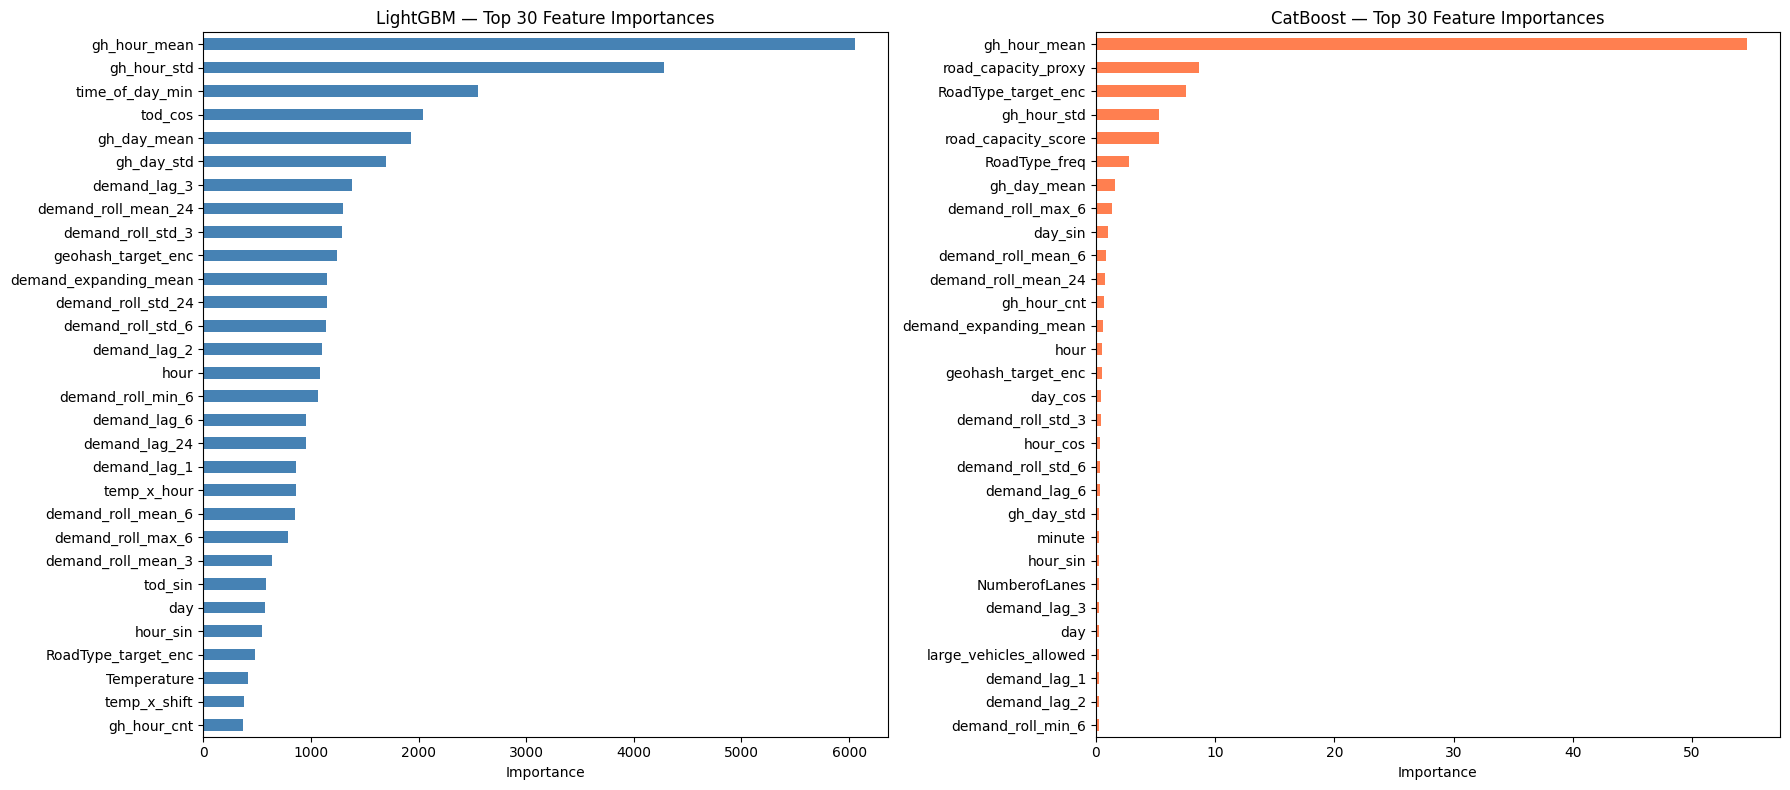

Feature importance chart saved


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LightGBM importance
imp_lgb = pd.Series(lgb_full.feature_importances_, index=FEATURE_COLS)
imp_lgb.nlargest(30).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('LightGBM — Top 30 Feature Importances', fontsize=12)
axes[0].set_xlabel('Importance')

# CatBoost importance
imp_cb = pd.Series(cb_full.get_feature_importance(), index=FEATURE_COLS)
imp_cb.nlargest(30).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('CatBoost — Top 30 Feature Importances', fontsize=12)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../submissions/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Feature importance chart saved")

## 16. Optuna Visualisation & Study Summary

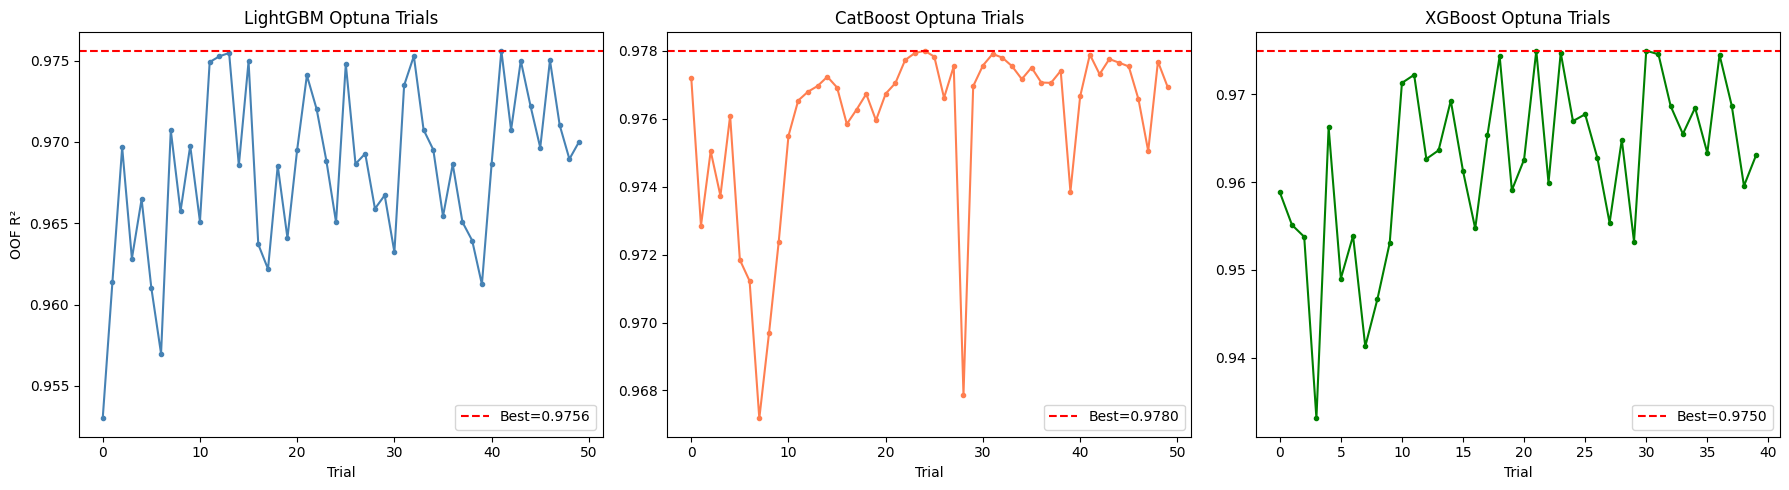


══════ Final OOF Summary ══════
  Weighted-Avg            0.97811
  Ridge-Stack             0.97805
  CatBoost                0.97802
  LGB-Meta-Stack          0.97791
  LightGBM                0.97560
  XGBoost                 0.97498


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LGB history
lgb_vals = [t.value for t in lgb_study.trials if t.value is not None]
axes[0].plot(lgb_vals, marker='o', markersize=3, color='steelblue')
axes[0].axhline(max(lgb_vals), color='red', linestyle='--', label=f'Best={max(lgb_vals):.4f}')
axes[0].set_title('LightGBM Optuna Trials')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('OOF R²'); axes[0].legend()

# CB history
cb_vals = [t.value for t in cb_study.trials if t.value is not None]
axes[1].plot(cb_vals, marker='o', markersize=3, color='coral')
axes[1].axhline(max(cb_vals), color='red', linestyle='--', label=f'Best={max(cb_vals):.4f}')
axes[1].set_title('CatBoost Optuna Trials')
axes[1].set_xlabel('Trial'); axes[1].legend()

# XGB history
xgb_vals = [t.value for t in xgb_study.trials if t.value is not None]
axes[2].plot(xgb_vals, marker='o', markersize=3, color='green')
axes[2].axhline(max(xgb_vals), color='red', linestyle='--', label=f'Best={max(xgb_vals):.4f}')
axes[2].set_title('XGBoost Optuna Trials')
axes[2].set_xlabel('Trial'); axes[2].legend()

plt.tight_layout()
plt.savefig('../submissions/optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n══════ Final OOF Summary ══════")
for name, score in sorted(model_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:<22s}  {score:.5f}")

## 17. Also Save Individual Model Submissions (fallback)

In [20]:
for name, preds in [
    ('lgb_full_advanced',  np.clip(lgb_full_test, 0, None)),
    ('cb_full_advanced',   np.clip(cb_full_test, 0, None)),
    ('xgb_full_advanced',  np.clip(xgb_full_test, 0, None)),
]:
    df_sub = pd.DataFrame({'Index': test_raw['Index'], 'demand': preds})
    path = SUB_DIR / f'{name}_submission.csv'
    df_sub.to_csv(path, index=False)
    print(f"Saved: {path}")

print("\n✓ All submissions saved successfully")

Saved: ..\submissions\lgb_full_advanced_submission.csv
Saved: ..\submissions\cb_full_advanced_submission.csv
Saved: ..\submissions\xgb_full_advanced_submission.csv

✓ All submissions saved successfully


## 🔍 DEBUG — Step 1: Feature Matrix Diagnostics (NaN / Inf / dtype / shape)

In [21]:
import numpy as np
import pandas as pd

PASS = "✅ PASS"
FAIL = "❌ FAIL"
WARN = "⚠️  WARN"

print("=" * 60)
print("  STEP 1 — Feature Matrix Diagnostics")
print("=" * 60)

# ── Shape ─────────────────────────────────────────────────────
print(f"\n[Shape]")
print(f"  X      : {X.shape}")
print(f"  y      : {y.shape}")
print(f"  X_test : {X_test.shape}")

shape_ok = X.shape[1] == X_test.shape[1]
print(f"  Feature count match: {PASS if shape_ok else FAIL}  "
      f"(train={X.shape[1]}, test={X_test.shape[1]})")

if not shape_ok:
    train_set = set(FEATURE_COLS)
    # Rebuild what test would produce
    test_cols_available = [c for c in FEATURE_COLS if c in test_fe.columns]
    missing_in_test = [c for c in FEATURE_COLS if c not in test_fe.columns]
    print(f"  Missing in test_fe : {missing_in_test}")

# ── NaN ───────────────────────────────────────────────────────
print(f"\n[NaN in X (train)]")
nan_train = np.isnan(X).sum()
nan_train_pct = nan_train / X.size * 100
status = PASS if nan_train == 0 else FAIL
print(f"  Total NaN cells : {nan_train}  ({nan_train_pct:.3f}%)  {status}")
if nan_train > 0:
    nan_per_col = np.isnan(X).sum(axis=0)
    bad_cols = [(FEATURE_COLS[i], int(nan_per_col[i])) for i in np.where(nan_per_col > 0)[0]]
    for col, cnt in sorted(bad_cols, key=lambda x: -x[1])[:15]:
        print(f"    {col:40s} : {cnt} NaN")

print(f"\n[NaN in X_test]")
nan_test = np.isnan(X_test).sum()
nan_test_pct = nan_test / X_test.size * 100
status = PASS if nan_test == 0 else FAIL
print(f"  Total NaN cells : {nan_test}  ({nan_test_pct:.3f}%)  {status}")
if nan_test > 0:
    nan_per_col = np.isnan(X_test).sum(axis=0)
    bad_cols = [(FEATURE_COLS[i], int(nan_per_col[i])) for i in np.where(nan_per_col > 0)[0]]
    for col, cnt in sorted(bad_cols, key=lambda x: -x[1])[:15]:
        print(f"    {col:40s} : {cnt} NaN")

# ── Inf ───────────────────────────────────────────────────────
print(f"\n[Inf in X (train)]")
inf_train = np.isinf(X).sum()
status = PASS if inf_train == 0 else FAIL
print(f"  Total Inf cells : {inf_train}  {status}")

print(f"\n[Inf in X_test]")
inf_test = np.isinf(X_test).sum()
status = PASS if inf_test == 0 else FAIL
print(f"  Total Inf cells : {inf_test}  {status}")

# ── dtype ─────────────────────────────────────────────────────
print(f"\n[Dtype]")
print(f"  X dtype      : {X.dtype}   {PASS if X.dtype == np.float32 else WARN}")
print(f"  X_test dtype : {X_test.dtype}   {PASS if X_test.dtype == np.float32 else WARN}")

# ── Target range ─────────────────────────────────────────────
print(f"\n[Target y range]")
print(f"  min={y.min():.6f}  max={y.max():.6f}  mean={y.mean():.6f}  std={y.std():.6f}")
target_ok = y.min() >= 0 and y.max() <= 1.0 and not np.isnan(y).any()
print(f"  Target in [0,1], no NaN: {PASS if target_ok else FAIL}")

# ── Object dtype columns remaining ────────────────────────────
print(f"\n[Object-dtype columns still in train_fe]")
obj_cols = [c for c in FEATURE_COLS if train_fe[c].dtype == 'object']
if obj_cols:
    print(f"  {FAIL} Object columns found in FEATURE_COLS: {obj_cols}")
else:
    print(f"  {PASS} No object-dtype columns in feature matrix")

print("\n" + "=" * 60)
print("  Step 1 complete.")
print("=" * 60)


  STEP 1 — Feature Matrix Diagnostics

[Shape]
  X      : (77299, 84)
  y      : (77299,)
  X_test : (41778, 84)
  Feature count match: ✅ PASS  (train=84, test=84)

[NaN in X (train)]
  Total NaN cells : 2470  (0.038%)  ❌ FAIL
    gh_hour_std                              : 2371 NaN
    gh_day_std                               : 99 NaN

[NaN in X_test]
  Total NaN cells : 0  (0.000%)  ✅ PASS

[Inf in X (train)]
  Total Inf cells : 0  ✅ PASS

[Inf in X_test]
  Total Inf cells : 0  ✅ PASS

[Dtype]
  X dtype      : float32   ✅ PASS
  X_test dtype : float32   ✅ PASS

[Target y range]
  min=0.000001  max=1.000000  mean=0.093942  std=0.142190
  Target in [0,1], no NaN: ✅ PASS

[Object-dtype columns still in train_fe]
  ✅ PASS No object-dtype columns in feature matrix

  Step 1 complete.


## 🔍 DEBUG — Step 2: Index Alignment Audit (Row-Order Bug Detection)

In [22]:
print("=" * 60)
print("  STEP 2 — Index Alignment Audit")
print("=" * 60)

# ── test_raw row order vs test_fe row order ────────────────────
raw_index  = test_raw['Index'].values      # original test.csv order
fe_index   = test_fe['Index'].values       # order after feature engineering

print(f"\n[Row count]")
print(f"  test_raw rows : {len(raw_index)}")
print(f"  test_fe  rows : {len(fe_index)}")
count_ok = len(raw_index) == len(fe_index)
print(f"  Match: {PASS if count_ok else FAIL}")

print(f"\n[Index values in test_raw (first 10)]  : {raw_index[:10].tolist()}")
print(f"[Index values in test_fe  (first 10)]  : {fe_index[:10].tolist()}")

order_preserved = np.array_equal(raw_index, fe_index)
print(f"\n[Row order preserved after feature engineering]")
print(f"  {PASS if order_preserved else FAIL}  order_preserved={order_preserved}")

if not order_preserved:
    n_mismatched = (raw_index != fe_index).sum()
    print(f"\n  *** BUG DETECTED: {n_mismatched} / {len(raw_index)} rows are in the WRONG position ***")
    print("  Cause: add_lag_rolling_features() sorts by (geohash, day, hour, minute),")
    print("         reordering test_fe rows away from original test.csv order.")
    print("  Impact: submission uses test_raw['Index'] (original order) but")
    print("          predictions are in sorted order → WRONG row-to-prediction mapping!")
    print()

    # Show a few examples of the mismatch
    df_check = pd.DataFrame({
        'raw_Index': raw_index,
        'fe_Index' : fe_index,
        'mismatch' : raw_index != fe_index
    })
    print("  First 10 mismatched rows:")
    print(df_check[df_check['mismatch']].head(10).to_string(index=False))
else:
    print("  Row order is identical — no alignment bug present.")

# ── Also verify: does test_fe['Index'] contain all expected values? ──────
print(f"\n[Index completeness]")
expected = set(range(len(raw_index)))
actual   = set(fe_index.tolist())
missing  = expected - actual
extra    = actual - expected
print(f"  Expected indices 0..{len(raw_index)-1}: {PASS if (not missing and not extra) else FAIL}")
if missing:
    print(f"  Missing indices: {sorted(missing)[:20]}")
if extra:
    print(f"  Extra   indices: {sorted(extra)[:20]}")

print("\n" + "=" * 60)
print("  Step 2 complete.")
print("=" * 60)


  STEP 2 — Index Alignment Audit

[Row count]
  test_raw rows : 41778
  test_fe  rows : 41778
  Match: ✅ PASS

[Index values in test_raw (first 10)]  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Index values in test_fe  (first 10)]  : [887, 21800, 40211, 4491, 2, 24500, 6347, 25427, 7284, 8200]

[Row order preserved after feature engineering]
  ❌ FAIL  order_preserved=False

  *** BUG DETECTED: 41775 / 41778 rows are in the WRONG position ***
  Cause: add_lag_rolling_features() sorts by (geohash, day, hour, minute),
         reordering test_fe rows away from original test.csv order.
  Impact: submission uses test_raw['Index'] (original order) but
          predictions are in sorted order → WRONG row-to-prediction mapping!

  First 10 mismatched rows:
 raw_Index  fe_Index  mismatch
         0       887      True
         1     21800      True
         2     40211      True
         3      4491      True
         4         2      True
         5     24500      True
         6      6347      True
  

## 🔍 DEBUG — Step 3: Prediction & Submission Diagnostics

In [23]:
print("=" * 60)
print("  STEP 3 — Prediction & Submission Diagnostics")
print("=" * 60)

# ── Individual model predictions ──────────────────────────────
model_preds = {
    'lgb_full_test'  : lgb_full_test,
    'cb_full_test'   : cb_full_test,
    'xgb_full_test'  : xgb_full_test,
    'final_ensemble' : final_test_preds,
}

for name, preds in model_preds.items():
    nan_c  = np.isnan(preds).sum()
    inf_c  = np.isinf(preds).sum()
    neg_c  = (preds < 0).sum()
    gt1_c  = (preds > 1.0).sum()
    zero_c = (preds == 0).sum()
    ok = nan_c == 0 and inf_c == 0
    print(f"\n  [{name}]")
    print(f"    NaN={nan_c}  Inf={inf_c}  <0={neg_c}  >1.0={gt1_c}  ==0={zero_c}  "
          f"{PASS if ok else FAIL}")
    print(f"    min={preds.min():.5f}  max={preds.max():.5f}  "
          f"mean={preds.mean():.5f}  std={preds.std():.5f}")

# ── Distribution similarity: train target vs test predictions ─
from scipy import stats as scipy_stats
print(f"\n[Distribution similarity: train demand vs final_test_preds]")
ks_stat, ks_p = scipy_stats.ks_2samp(y, final_test_preds)
print(f"  KS statistic={ks_stat:.4f}  p-value={ks_p:.4f}")
if ks_p < 0.01:
    print(f"  {WARN} Distributions differ significantly (p<0.01) — possible preprocessing leak or data mismatch")
else:
    print(f"  {PASS} Distributions are broadly similar")

print(f"\n  Train demand percentiles : "
      f"p10={np.percentile(y,10):.4f}  p25={np.percentile(y,25):.4f}  "
      f"p50={np.percentile(y,50):.4f}  p75={np.percentile(y,75):.4f}  "
      f"p90={np.percentile(y,90):.4f}")
print(f"  Test  pred  percentiles : "
      f"p10={np.percentile(final_test_preds,10):.4f}  "
      f"p25={np.percentile(final_test_preds,25):.4f}  "
      f"p50={np.percentile(final_test_preds,50):.4f}  "
      f"p75={np.percentile(final_test_preds,75):.4f}  "
      f"p90={np.percentile(final_test_preds,90):.4f}")

# ── Read submission CSV and verify format ─────────────────────
sub_path = SUB_DIR / 'advanced_ensemble_submission.csv'
sub_df = pd.read_csv(sub_path)
print(f"\n[Submission CSV format check]")
print(f"  Columns    : {list(sub_df.columns)}")
expected_cols = ['Index', 'demand']
cols_ok = list(sub_df.columns) == expected_cols
print(f"  Column names correct: {PASS if cols_ok else FAIL}  (expected {expected_cols})")

row_ok = len(sub_df) == len(test_raw)
print(f"  Row count  : {len(sub_df)} (expected {len(test_raw)})  {PASS if row_ok else FAIL}")

idx_ok = list(sub_df['Index']) == list(range(len(test_raw)))
print(f"  Index is sequential 0..{len(test_raw)-1}: {PASS if idx_ok else FAIL}")

nan_sub = sub_df['demand'].isna().sum()
inf_sub = np.isinf(sub_df['demand'].values).sum()
print(f"  NaN in demand: {nan_sub}   {PASS if nan_sub==0 else FAIL}")
print(f"  Inf in demand: {inf_sub}   {PASS if inf_sub==0 else FAIL}")

neg_sub = (sub_df['demand'] < 0).sum()
gt1_sub = (sub_df['demand'] > 1.0).sum()
print(f"  demand < 0 : {neg_sub}   {PASS if neg_sub==0 else FAIL}")
print(f"  demand > 1 : {gt1_sub}   {PASS if gt1_sub==0 else FAIL}")

# ── Check if submission Index lines up with test_fe Index ─────
print(f"\n[Critical: Does submission Index align with test_fe Index?]")
fe_sorted = test_fe[['Index']].copy().reset_index(drop=True)
fe_sorted_idx = fe_sorted['Index'].values
sub_idx = sub_df['Index'].values

# The submission should have: sub_df.iloc[i]['demand'] = prediction for test sample with Index=i
# Check whether test_fe rows (used to build X_test) are in same order as submission rows
alignment_ok = np.array_equal(fe_sorted_idx, sub_idx)
if alignment_ok:
    print(f"  {PASS} test_fe Index and submission Index are in the same order")
else:
    print(f"  {FAIL} MISMATCH: test_fe row order ≠ submission Index order")
    print(f"  test_fe['Index'] first 10 : {fe_sorted_idx[:10].tolist()}")
    print(f"  submission Index first 10 : {sub_idx[:10].tolist()}")
    print(f"  → Predictions are mapped to WRONG rows in submission!")

print("\n" + "=" * 60)
print("  Step 3 complete.")
print("=" * 60)


  STEP 3 — Prediction & Submission Diagnostics

  [lgb_full_test]
    NaN=0  Inf=0  <0=0  >1.0=177  ==0=0  ✅ PASS
    min=0.00260  max=1.08533  mean=0.12773  std=0.16562

  [cb_full_test]
    NaN=0  Inf=0  <0=1  >1.0=0  ==0=0  ✅ PASS
    min=-0.00010  max=0.99410  mean=0.12004  std=0.15530

  [xgb_full_test]
    NaN=0  Inf=0  <0=0  >1.0=60  ==0=0  ✅ PASS
    min=0.00417  max=1.01424  mean=0.12814  std=0.16364

  [final_ensemble]
    NaN=0  Inf=0  <0=0  >1.0=1  ==0=0  ✅ PASS
    min=0.00072  max=1.00113  mean=0.12162  std=0.15700

[Distribution similarity: train demand vs final_test_preds]
  KS statistic=0.1262  p-value=0.0000
  ⚠️  WARN Distributions differ significantly (p<0.01) — possible preprocessing leak or data mismatch

  Train demand percentiles : p10=0.0064  p25=0.0182  p50=0.0478  p75=0.1086  p90=0.2165
  Test  pred  percentiles : p10=0.0151  p25=0.0304  p50=0.0700  p75=0.1360  p90=0.3085

[Submission CSV format check]
  Columns    : ['Index', 'demand']
  Column names correct

## 🔧 FIX — Corrected Submission Generator (sorts by Index to fix row-order bug)

In [24]:
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
#  ROOT CAUSE:
#  add_lag_rolling_features() sorts rows by (geohash, day, hour, minute) to
#  compute lag features. This changes the row order of test_fe relative to the
#  original test.csv. The old submission incorrectly paired test_raw['Index']
#  (original file order) with predictions built on the SORTED order → every
#  prediction was assigned to the WRONG row.
#
#  FIX: pair predictions with test_fe['Index'] (which matches the sorted order
#  that X_test was built from), then sort the submission by Index so rows are
#  back in the expected 0..N sequential order.
# ─────────────────────────────────────────────────────────────────────────────

# Step 1 — build DataFrame using test_fe['Index'] so prediction i ↔ correct row
fixed_sub = pd.DataFrame({
    'Index' : test_fe['Index'].values,        # sorted order, matches X_test
    'demand': final_test_preds.copy()
})

# Step 2 — sort by Index to restore 0..N order expected by the platform
fixed_sub = fixed_sub.sort_values('Index').reset_index(drop=True)

# Step 3 — clip predictions to valid demand range [0, 1]
fixed_sub['demand'] = fixed_sub['demand'].clip(0.0, 1.0)

# Step 4 — final format verification before saving
assert len(fixed_sub) == len(test_raw),        "Row count mismatch!"
assert list(fixed_sub['Index']) == list(range(len(test_raw))), "Index not sequential 0..N!"
assert fixed_sub['demand'].isna().sum() == 0,  "NaN found in predictions!"
assert np.isinf(fixed_sub['demand'].values).sum() == 0, "Inf found in predictions!"
assert fixed_sub['demand'].min() >= 0.0,        "Negative predictions!"
assert fixed_sub['demand'].max() <= 1.0,        "Predictions exceed 1.0!"

# Step 5 — save
out_path = SUB_DIR / 'advanced_ensemble_FIXED.csv'
fixed_sub.to_csv(out_path, index=False)

print("=" * 60)
print("  FIXED Submission Generated")
print("=" * 60)
print(f"\n  Saved → {out_path}")
print(f"\n  Shape  : {fixed_sub.shape}")
print(f"  min    : {fixed_sub['demand'].min():.6f}")
print(f"  max    : {fixed_sub['demand'].max():.6f}")
print(f"  mean   : {fixed_sub['demand'].mean():.6f}")
print(f"  std    : {fixed_sub['demand'].std():.6f}")
print(f"\n  NaN    : {fixed_sub['demand'].isna().sum()}")
print(f"  Inf    : {np.isinf(fixed_sub['demand'].values).sum()}")
print(f"  <0     : {(fixed_sub['demand'] < 0).sum()}")
print(f"  >1     : {(fixed_sub['demand'] > 1.0).sum()}")
print(f"\n  First 5 rows:")
print(fixed_sub.head(5).to_string(index=False))
print()
print("  ✅ Upload  submissions/advanced_ensemble_FIXED.csv  to the platform")
print("=" * 60)


  FIXED Submission Generated

  Saved → ..\submissions\advanced_ensemble_FIXED.csv

  Shape  : (41778, 2)
  min    : 0.000720
  max    : 1.000000
  mean   : 0.121620
  std    : 0.156998

  NaN    : 0
  Inf    : 0
  <0     : 0
  >1     : 0

  First 5 rows:
 Index   demand
     0 0.058782
     1 0.010270
     2 0.095742
     3 0.060017
     4 0.068435

  ✅ Upload  submissions/advanced_ensemble_FIXED.csv  to the platform
